In [1]:
from pathlib import Path
import os
import warnings
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

warnings.filterwarnings("ignore", message="All-NaN slice encountered", category=RuntimeWarning)

# -----------------------------
# FEATURE WINDOWS (emission + absorption/masked)
# -----------------------------

# Rest-frame wavelengths [Å]
REST = {
    # emission lines used downstream
    "Hb_4861":      {"rest": [4861.33],                      "half": 6.0,  "kind": "em"},
    "OIII_4959":    {"rest": [4958.91],                      "half": 6.0,  "kind": "em"},
    "OIII_5007":    {"rest": [5006.84],                      "half": 6.0,  "kind": "em"},
    "HaNII_blend":  {"rest": [6548.05, 6562.80, 6583.45],    "half": 10.0, "kind": "em"},  # broad to cover blend
    "SII_doublet":  {"rest": [6716.44, 6730.82],             "half": 8.0,  "kind": "em"},

    # classic absorption/masked problematic regions
    "MgB_triplet":  {"rest": [5167.32, 5172.68, 5183.60],    "half": 10.0, "kind": "abs"},
    "Fe_5270":      {"rest": [5270.40],                      "half": 8.0,  "kind": "abs"},
    "Fe_5335":      {"rest": [5335.00],                      "half": 8.0,  "kind": "abs"},
    "NaD_doublet":  {"rest": [5889.95, 5895.92],             "half": 12.0, "kind": "abs"},

    # only available if your fit goes red enough (9100 case)
    "CaT_triplet":  {"rest": [8498.02, 8542.09, 8662.14],    "half": 12.0, "kind": "abs"},
}

# -----------------------------
# USER SETTINGS
# -----------------------------
base = Path.cwd()

run_ids_9100 = {
    8:  "IC3392_v3tk_9100_mask_uptoCONT_MDEG8",
    12: "IC3392_v3tk_9100_mask_uptoCONT_MDEG12",
    16: "IC3392_v3tk_9100_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_9100_mask_uptoCONT_MDEG20",
}

run_ids_7000 = {
    8:  "IC3392_v3tk_mask_uptoCONT",
    12: "IC3392_v3tk_mask_uptoCONT_MDEG12",
    16: "IC3392_v3tk_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_mask_uptoCONT_MDEG20",
}

if sorted(run_ids_9100) != sorted(run_ids_7000):
    raise ValueError("MDEG keys mismatch between 9100 and 7000 datasets")

MDEGS = sorted(run_ids_9100)
run_ids = run_ids_9100  # keep legacy name for later cells

linecube_name = lambda rid: base / rid / f"{rid}_line_cube.fits"

ORIG_CUBE_PATH = Path("/Users/Igniz/nGISTENV/ngist_supplementary_public/ngistTutorial/inputData/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits")

windows = {
    "cont_5050_5120": (5050.0, 5120.0),
    "cont_5218_5485": (5218.0, 5485.0),
    "cont_5600_5650": (5600.0, 5650.0),
    "cont_6000_6200": (6000.0, 6200.0),
    "cont_6400_6500": (6400.0, 6500.0),
    "Hb_edge_4800_4920": (4800.0, 4920.0),
    "OIII_edge_4940_5060": (4940.0, 5060.0),
    "HaNII_edge_6500_6625": (6500.0, 6625.0),
    "SII_edge_6680_6760": (6680.0, 6760.0),
}

NSAMPLE  = 100000
STRIDE   = 4
NCPU     = min(os.cpu_count() or 8, 16)
DENOM_FLOOR_FRAC = 1e-3
CONT_FLOOR_FRAC = 1e-3
CONT_WIN = (5218.0, 5485.0)

# -----------------------------
# FITS HELPERS
# -----------------------------
def wave_from_fits_header(hdr):
    crval = hdr["CRVAL3"]
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3"))
    crpix = hdr.get("CRPIX3", 1.0)
    n = hdr["NAXIS3"]
    pix = np.arange(n) + 1
    return crval + (pix - crpix) * cdelt

def open_memmap_cube(path):
    hdul = fits.open(path, memmap=True)
    cube = hdul[0].data
    wave = wave_from_fits_header(hdul[0].header)
    return hdul, cube, wave

def open_memmap_cube_anyhdu(path: Path):
    hdul = fits.open(path, memmap=True)
    hdu = None
    for hh in hdul:
        if getattr(hh, "data", None) is None:
            continue
        if hh.data is None:
            continue
        if hh.data.ndim == 3 and hh.name.upper() != "STAT":
            hdu = hh
            break
    if hdu is None:
        raise RuntimeError(f"No 3D flux cube found in {path}")

    if "STAT" not in hdul:
        raise RuntimeError(f"STAT extension not found in {path}")
    stat_hdu = hdul["STAT"]
    if getattr(stat_hdu, "data", None) is None or stat_hdu.data.ndim != 3:
        raise RuntimeError(f"STAT extension is not a 3D variance cube in {path}")

    cube = hdu.data
    var_cube = stat_hdu.data
    wave = wave_from_fits_header(hdu.header)
    return hdul, cube, var_cube, wave

def continuum_level_map(cube, wave, w1, w2):
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        raise RuntimeError("Continuum window has no samples on this wavelength grid.")
    return np.nanmedian(cube[idx, :, :], axis=0)

def noise_level_map(var_cube, wave, w1, w2):
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        raise RuntimeError("Noise window has no samples on this wavelength grid.")
    med_var = np.nanmedian(var_cube[idx, :, :], axis=0)
    return np.sqrt(np.clip(med_var, 0.0, None))

def interp_spec_to_wave(spec_in, wave_in, wave_out):
    ok = np.isfinite(spec_in) & np.isfinite(wave_in)
    if ok.sum() < 2:
        return np.full_like(wave_out, np.nan, dtype=float)
    return np.interp(wave_out, wave_in[ok], spec_in[ok], left=np.nan, right=np.nan)


def load_dataset(run_map, label):
    hduls, cubes, waves = {}, {}, {}
    for mdeg, rid in run_map.items():
        f = linecube_name(rid)
        hdul, cube, wave = open_memmap_cube(f)
        hduls[mdeg] = hdul
        cubes[mdeg] = cube
        waves[mdeg] = wave
        print(f"[LOAD {label}] MDEG={mdeg:>2}  file={f.name}  shape={cube.shape}")

    ref_spatial = cubes[MDEGS[0]].shape[1:]
    for mdeg in MDEGS:
        if cubes[mdeg].shape[1:] != ref_spatial:
            raise ValueError(f"{label}: spatial shape mismatch at MDEG {mdeg}: {cubes[mdeg].shape[1:]} vs {ref_spatial}")
    return hduls, cubes, waves[MDEGS[0]], ref_spatial


# -----------------------------
# LOAD BOTH FITTING-RANGE DATASETS
# -----------------------------
hduls_9100, cubes_9100, wave_9100, spatial_9100 = load_dataset(run_ids_9100, "9100")
hduls_7000, cubes_7000, wave_7000, spatial_7000 = load_dataset(run_ids_7000, "7000")

if spatial_9100 != spatial_7000:
    raise ValueError("Cross-range spatial shape mismatch between 9100 and 7000 datasets")

if not np.allclose(wave_9100[: min(len(wave_9100), len(wave_7000))], wave_7000[: min(len(wave_9100), len(wave_7000))], atol=1e-6, rtol=0):
    print("[WARN] wavelength grids differ; interpolation will be used where direct subtraction is needed")

ref_wave = wave_7000

datasets = {
    "9100": {"hduls": hduls_9100, "cubes": cubes_9100, "wave": wave_9100},
    "7000": {"hduls": hduls_7000, "cubes": cubes_7000, "wave": wave_7000},
}

# legacy aliases retained for downstream cells
hduls = hduls_9100
cubes = cubes_9100

# Load ORIGINAL flux cube + STAT variance cube
hdul_orig, cube_orig, var_orig, wave_orig = open_memmap_cube_anyhdu(ORIG_CUBE_PATH)
print(f"[LOAD ORIG] {ORIG_CUBE_PATH.name}  shape={cube_orig.shape}")

if cube_orig.shape[1:] != spatial_9100:
    raise ValueError(f"ORIG cube spatial shape mismatch: {cube_orig.shape[1:]} vs {spatial_9100}")
if var_orig.shape != cube_orig.shape:
    raise ValueError(f"STAT variance shape mismatch: {var_orig.shape} vs {cube_orig.shape}")

cont_map = continuum_level_map(cube_orig, wave_orig, *CONT_WIN)
cont_finite = np.isfinite(cont_map)
cont_scale = np.nanpercentile(np.abs(cont_map[cont_finite]), 90)
CONT_FLOOR = cont_scale * CONT_FLOOR_FRAC
print(f"[CONT] p90(|cont|)={cont_scale:.4g}, floor={CONT_FLOOR:.4g}")

noise_map = noise_level_map(var_orig, wave_orig, *CONT_WIN)
noise_finite = np.isfinite(noise_map)
noise_scale = np.nanpercentile(noise_map[noise_finite], 50)
print(f"[NOISE] median sigma({CONT_WIN[0]:.0f}-{CONT_WIN[1]:.0f})={noise_scale:.4g}")


# -----------------------------
# BUILD RANDOM SPAXEL SAMPLE (valid in both ranges)
# -----------------------------
w1_ref, w2_ref = windows["cont_5218_5485"]
idx_ref_9100 = (wave_9100 >= w1_ref) & (wave_9100 <= w2_ref)
idx_ref_7000 = (wave_7000 >= w1_ref) & (wave_7000 <= w2_ref)

sub_9100_ref = cubes_9100[MDEGS[0]][idx_ref_9100, :, :]
sub_7000_ref = cubes_7000[MDEGS[0]][idx_ref_7000, :, :]
valid_ref = np.isfinite(sub_9100_ref).any(axis=0) & np.isfinite(sub_7000_ref).any(axis=0)

yy, xx = np.where(valid_ref)
n_valid = yy.size
if n_valid == 0:
    raise RuntimeError("No valid spaxels found in both ranges for the reference window")

rng = np.random.default_rng(42)
take = min(NSAMPLE, n_valid)
sel_idx = rng.choice(n_valid, size=take, replace=False)
ys = yy[sel_idx]
xs = xx[sel_idx]
print(f"[SAMPLE] Using {take} spaxels out of {n_valid} jointly-valid spaxels")
print(f"[PARALLEL] Using {NCPU} threads")

cont_samp = cont_map[ys, xs]
cont_samp_denom = np.sign(cont_samp) * np.maximum(np.abs(cont_samp), CONT_FLOOR)
noise_samp = noise_map[ys, xs]

def estimate_z_from_ha_nii_blend(wave, spec, search=(6500.0, 6625.0), min_peak=5.0):
    """
    Estimate z by finding the Hα+[NII] blend position via a simple matched score.
    - wave: 1D wavelength array
    - spec: 1D spectrum (line cube, so emission should be positive)
    - min_peak: require max(spec) in search window > min_peak * median(|spec|) over that window,
                otherwise return z=0.
    """
    w1, w2 = search
    m = (wave >= w1) & (wave <= w2) & np.isfinite(spec)
    if m.sum() < 10:
        return 0.0

    ww = wave[m]
    ss = spec[m]

    # Require a detectable peak to avoid garbage z from noise-only spectra
    baseline = np.nanmedian(np.abs(ss))
    peak = np.nanmax(ss)
    if not np.isfinite(peak) or baseline <= 0 or peak < min_peak * baseline:
        return 0.0

    # Build a score assuming ww[i] is Hα, and sample at Hα +/- separations for [NII]
    d1 = 6562.80 - 6548.05  # 14.75
    d2 = 6583.45 - 6562.80  # 20.65

    # Candidate Hα wavelengths are ww itself
    ha = ww
    s_ha     = np.interp(ha,           ww, ss, left=np.nan, right=np.nan)
    s_nii6548= np.interp(ha - d1,      ww, ss, left=np.nan, right=np.nan)
    s_nii6583= np.interp(ha + d2,      ww, ss, left=np.nan, right=np.nan)

    score = s_ha + 0.7*s_nii6548 + 0.7*s_nii6583  # weights are not critical
    j = np.nanargmax(score)
    lam_ha_obs = ha[j]

    z = lam_ha_obs / 6562.80 - 1.0
    if not np.isfinite(z):
        return 0.0
    return float(z)

def build_obs_windows(z):
    """
    Convert REST dict to observed-frame windows (w1,w2) using z.
    Window bounds cover all components in 'rest' list plus +/- half.
    """
    obs = {}
    for name, meta in REST.items():
        rests = np.array(meta["rest"], dtype=float)
        half = float(meta["half"])
        lam_obs = rests * (1.0 + z)
        w1 = float(np.min(lam_obs) - half)
        w2 = float(np.max(lam_obs) + half)
        obs[name] = {"w1": w1, "w2": w2, "kind": meta["kind"]}
    return obs

# -----------------------------
# Use known redshift from nGIST config / your run
# -----------------------------
Z_INPUT = 0.005566   # <-- nGIST input redshift for IC3392
z_est = Z_INPUT
print(f"[Z] using fixed redshift z = {z_est:.6f}")

obs_windows = build_obs_windows(z_est)

# sanity print
for k in obs_windows:
    w1, w2 = obs_windows[k]["w1"], obs_windows[k]["w2"]
    print(f"  {k:12s}  kind={obs_windows[k]['kind']:3s}  [{w1:.1f}, {w2:.1f}] Å")


# -----------------------------
# Metrics: where do differences peak?
# -----------------------------

def window_mask(wave, w1, w2):
    return (wave >= w1) & (wave <= w2)

def peak_metrics_from_curve(arr):
    """
    arr is 1D curve of (delta / sigma) in a window.
    Return peak_abs, peak_pos, peak_neg.
    """
    if arr is None or arr.size == 0:
        return np.nan, np.nan, np.nan
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan, np.nan, np.nan
    return float(np.nanmax(np.abs(arr))), float(np.nanmax(arr)), float(np.nanmin(arr))

def interp_cube_to_waveout_window(cube_in, wave_in, wave_out_win, y, x):
    """
    Vector-free: interpolate a single spaxel spectrum cube_in[:,y,x] onto wave_out_win.
    """
    spec = cube_in[:, y, x]
    ok = np.isfinite(spec) & np.isfinite(wave_in)
    if ok.sum() < 2:
        return np.full_like(wave_out_win, np.nan, dtype=float)
    return np.interp(wave_out_win, wave_in[ok], spec[ok], left=np.nan, right=np.nan)

def spaxel_feature_table(x, y, base_mdeg=8, mdegs=(8,12,16,20)):
    """
    Build a DataFrame of peak metrics for:
    - Range effect: (9100-7000) at each MDEG, evaluated on wave_7000
    - MDEG effect within each range: (MDEG - base) for 7000 and 9100
    Normalization: scalar sigma = noise_map[y,x]
    """
    sigma = noise_map[y, x]
    if not np.isfinite(sigma) or sigma <= 0:
        raise RuntimeError("Invalid sigma at this spaxel (noise_map).")

    rows = []
    for feat, meta in obs_windows.items():
        w1, w2 = meta["w1"], meta["w2"]

        # Skip features not covered by each grid where relevant
        covered_7000 = (w1 <= wave_7000.max()) and (w2 >= wave_7000.min())
        covered_9100 = (w1 <= wave_9100.max()) and (w2 >= wave_9100.min())

        # Build window wavelength arrays
        m7000 = window_mask(wave_7000, w1, w2) if covered_7000 else None
        m9100 = window_mask(wave_9100, w1, w2) if covered_9100 else None

        # --- Range effect (9100-7000) on 7000 grid ---
        for mdeg in mdegs:
            if covered_7000:
                wwin = wave_7000[m7000]
                s7000 = cubes_7000[mdeg][m7000, y, x]
                s9100_on_7000 = interp_cube_to_waveout_window(cubes_9100[mdeg], wave_9100, wwin, y, x)
                d = (s9100_on_7000 - s7000) / sigma
                pabs, ppos, pneg = peak_metrics_from_curve(d)
            else:
                pabs = ppos = pneg = np.nan

            rows.append({
                "feature": feat,
                "kind": meta["kind"],
                "comparison": f"range(9100-7000)@MDEG{mdeg}",
                "peak_abs": pabs,
                "peak_pos": ppos,
                "peak_neg": pneg,
            })

        # --- MDEG effect within 7000 ---
        for mdeg in mdegs:
            if mdeg == base_mdeg:
                continue
            if covered_7000:
                s = (cubes_7000[mdeg][m7000, y, x] - cubes_7000[base_mdeg][m7000, y, x]) / sigma
                pabs, ppos, pneg = peak_metrics_from_curve(s)
            else:
                pabs = ppos = pneg = np.nan

            rows.append({
                "feature": feat,
                "kind": meta["kind"],
                "comparison": f"mdeg({mdeg}-{base_mdeg})@7000",
                "peak_abs": pabs,
                "peak_pos": ppos,
                "peak_neg": pneg,
            })

        # --- MDEG effect within 9100 ---
        for mdeg in mdegs:
            if mdeg == base_mdeg:
                continue
            if covered_9100 and m9100 is not None and m9100.any():
                s = (cubes_9100[mdeg][m9100, y, x] - cubes_9100[base_mdeg][m9100, y, x]) / sigma
                pabs, ppos, pneg = peak_metrics_from_curve(s)
            else:
                pabs = ppos = pneg = np.nan

            rows.append({
                "feature": feat,
                "kind": meta["kind"],
                "comparison": f"mdeg({mdeg}-{base_mdeg})@9100",
                "peak_abs": pabs,
                "peak_pos": ppos,
                "peak_neg": pneg,
            })

    df = pd.DataFrame(rows)
    return df


# ---- single spaxel table ----
XPIX = 218
YPIX = 218
df_spx = spaxel_feature_table(XPIX, YPIX, base_mdeg=8, mdegs=(8,12,16,20))

# Show a compact pivot of peak_abs
pivot_spx = df_spx.pivot_table(index=["feature","kind"], columns="comparison", values="peak_abs", aggfunc="median")
display(pivot_spx)

[LOAD 9100] MDEG= 8  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG8_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=12  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG12_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=16  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG16_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=20  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG20_line_cube.fits  shape=(3459, 438, 437)
[LOAD 7000] MDEG= 8  file=IC3392_v3tk_mask_uptoCONT_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=12  file=IC3392_v3tk_mask_uptoCONT_MDEG12_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=16  file=IC3392_v3tk_mask_uptoCONT_MDEG16_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=20  file=IC3392_v3tk_mask_uptoCONT_MDEG20_line_cube.fits  shape=(1770, 438, 437)
[LOAD ORIG] IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits  shape=(3761, 438, 437)
[CONT] p90(|cont|)=68.17, floor=0.06817
[NOISE] median sigma(5218-5485)=4.953
[SAMPLE] Using 96620 spaxels out of 96620

,comparison,mdeg(12-8)@7000,mdeg(12-8)@9100,mdeg(16-8)@7000,mdeg(16-8)@9100,mdeg(20-8)@7000,mdeg(20-8)@9100,range(9100-7000)@MDEG12,range(9100-7000)@MDEG16,range(9100-7000)@MDEG20,range(9100-7000)@MDEG8
feature,kind,,,,,,,,,,
CaT_triplet,abs,NaN,0.150190,NaN,0.210703,NaN,0.202609,NaN,NaN,NaN,NaN
Fe_5270,abs,0.108590,0.150445,0.117300,0.076221,0.113899,0.075742,0.650640,0.561114,0.673195,0.722487
Fe_5335,abs,0.056762,0.130807,0.069664,0.103944,0.068954,0.076781,0.523558,0.479480,0.569887,0.483539
HaNII_blend,em,0.121604,0.199863,0.554978,0.168339,0.405902,0.101396,0.581568,0.333248,0.306823,0.676988
Hb_4861,em,0.081819,0.046666,0.714511,0.304821,0.526808,0.146018,1.432562,1.274838,1.186921,1.391246
MgB_triplet,abs,0.091310,0.172934,0.190327,0.083768,0.225077,0.061912,0.718946,0.742016,0.657736,0.790453
NaD_doublet,abs,0.094466,0.089069,0.057862,0.270221,0.082802,0.094803,0.228238,0.372038,0.287897,0.235435
OIII_4959,em,0.007736,0.108138,0.054512,0.095941,0.099327,0.068959,0.953633,0.780993,0.852230,0.903274
OIII_5007,em,0.065009,0.073939,0.175675,0.093065,0.155704,0.020055,0.856983,0.962297,1.009929,0.862473


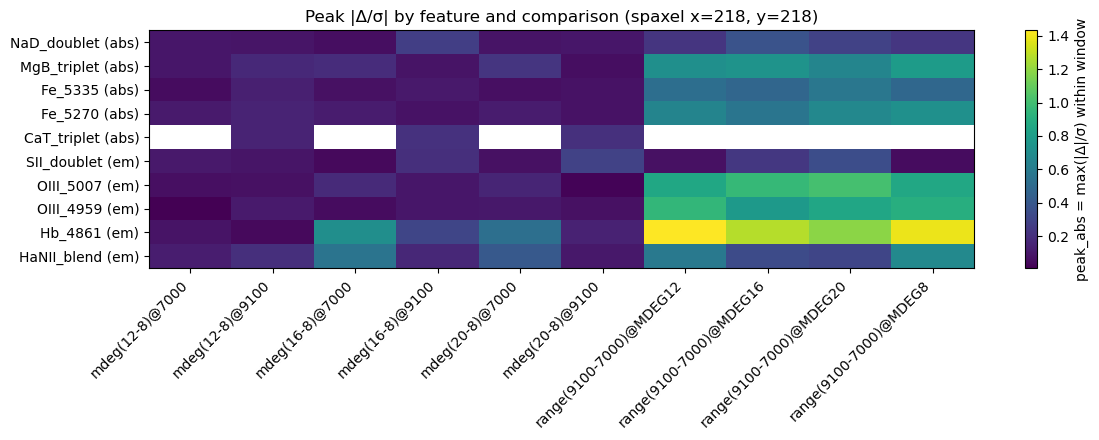

In [2]:
# -----------------------------
# Visual summary for the single spaxel
# -----------------------------
pivot = pivot_spx.copy()
pivot = pivot.replace([np.inf, -np.inf], np.nan)

# Order features: emission first then absorption
feat_order = list(pivot.index)
feat_order = sorted(feat_order, key=lambda t: (0 if t[1]=="em" else 1, t[0]))
pivot = pivot.loc[feat_order]

vals = pivot.values
fig, ax = plt.subplots(figsize=(12, max(4, 0.45*len(pivot.index))))
im = ax.imshow(vals, aspect="auto", origin="lower")

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels([f"{f} ({k})" for f,k in pivot.index])
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(list(pivot.columns), rotation=45, ha="right")

ax.set_title(f"Peak |Δ/σ| by feature and comparison (spaxel x={XPIX}, y={YPIX})")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("peak_abs = max(|Δ|/σ) within window")

plt.tight_layout()
plt.show()

In [3]:
# -----------------------------
# Sample statistics across (ys,xs): vectorized peak_abs distributions
# -----------------------------

def peakabs_over_sample(diff_slab, noise_samp):
    """
    diff_slab: (Nwin, Nspax) difference in flux units
    noise_samp: (Nspax,) scalar sigma
    returns: (Nspax,) peak_abs = max(|diff|/sigma)
    """
    denom = noise_samp[None, :]
    arr = diff_slab / denom
    return np.nanmax(np.abs(arr), axis=0)

def interp_slab_in_to_wave_out(cube_in, wave_in, wave_out_win, ys, xs):
    """
    Vectorized linear interpolation of cube_in onto wave_out_win for many spaxels.
    Returns slab_out with shape (Nwin, Nspax).
    """
    # indices in wave_in bracketing each wave_out point
    j = np.searchsorted(wave_in, wave_out_win)
    j = np.clip(j, 1, len(wave_in)-1)
    j0 = j - 1
    j1 = j

    x0 = wave_in[j0]
    x1 = wave_in[j1]
    w = (wave_out_win - x0) / (x1 - x0 + 1e-30)  # avoid /0

    y0 = cube_in[j0, :, :][:, ys, xs]  # (Nwin, Nspax)
    y1 = cube_in[j1, :, :][:, ys, xs]
    return y0*(1.0 - w[:, None]) + y1*(w[:, None])

def sample_feature_summary(base_mdeg=8, mdegs=(8,12,16,20), percentiles=(50, 84, 95, 99)):
    rows = []

    for feat, meta in obs_windows.items():
        w1, w2 = meta["w1"], meta["w2"]

        # Prepare masks / window wavelengths for each grid
        m7000 = window_mask(wave_7000, w1, w2)
        m9100 = window_mask(wave_9100, w1, w2)

        # --- Range effect on 7000 grid (only if window overlaps 7000) ---
        if m7000.any():
            wwin = wave_7000[m7000]
            for mdeg in mdegs:
                slab7000 = cubes_7000[mdeg][m7000, :, :][:, ys, xs]  # (Nwin, Nspax)
                slab9100 = interp_slab_in_to_wave_out(cubes_9100[mdeg], wave_9100, wwin, ys, xs)
                diff = slab9100 - slab7000
                peak = peakabs_over_sample(diff, noise_samp)

                rows.append({
                    "feature": feat, "kind": meta["kind"],
                    "comparison": f"range(9100-7000)@MDEG{mdeg}",
                    **{f"p{p}": float(np.nanpercentile(peak, p)) for p in percentiles}
                })

        # --- MDEG effect within 7000 ---
        if m7000.any():
            slab_base = cubes_7000[base_mdeg][m7000, :, :][:, ys, xs]
            for mdeg in mdegs:
                if mdeg == base_mdeg:
                    continue
                slab = cubes_7000[mdeg][m7000, :, :][:, ys, xs]
                diff = slab - slab_base
                peak = peakabs_over_sample(diff, noise_samp)

                rows.append({
                    "feature": feat, "kind": meta["kind"],
                    "comparison": f"mdeg({mdeg}-{base_mdeg})@7000",
                    **{f"p{p}": float(np.nanpercentile(peak, p)) for p in percentiles}
                })

        # --- MDEG effect within 9100 ---
        if m9100.any():
            slab_base = cubes_9100[base_mdeg][m9100, :, :][:, ys, xs]
            for mdeg in mdegs:
                if mdeg == base_mdeg:
                    continue
                slab = cubes_9100[mdeg][m9100, :, :][:, ys, xs]
                diff = slab - slab_base
                peak = peakabs_over_sample(diff, noise_samp)

                rows.append({
                    "feature": feat, "kind": meta["kind"],
                    "comparison": f"mdeg({mdeg}-{base_mdeg})@9100",
                    **{f"p{p}": float(np.nanpercentile(peak, p)) for p in percentiles}
                })

    return pd.DataFrame(rows)

df_samp = sample_feature_summary(base_mdeg=8, mdegs=(8,12,16,20), percentiles=(50,84,95,99))

# Compact view: focus on p95 peak_abs
pivot_p95 = df_samp.pivot_table(index=["feature","kind"], columns="comparison", values="p95", aggfunc="median")
display(pivot_p95)

,comparison,mdeg(12-8)@7000,mdeg(12-8)@9100,mdeg(16-8)@7000,mdeg(16-8)@9100,mdeg(20-8)@7000,mdeg(20-8)@9100,range(9100-7000)@MDEG12,range(9100-7000)@MDEG16,range(9100-7000)@MDEG20,range(9100-7000)@MDEG8
feature,kind,,,,,,,,,,
CaT_triplet,abs,NaN,0.126095,NaN,0.192047,NaN,0.196606,NaN,NaN,NaN,NaN
Fe_5270,abs,0.089550,0.126495,0.108961,0.100000,0.113444,0.151484,0.347779,0.332871,0.360055,0.323538
Fe_5335,abs,0.073979,0.117210,0.104169,0.099804,0.130712,0.138727,0.344811,0.316950,0.364249,0.311112
HaNII_blend,em,0.574785,0.185338,0.645338,0.302490,0.665187,0.267429,1.069704,0.947829,1.008314,0.889091
Hb_4861,em,0.646160,0.127163,0.758961,0.384422,0.791364,0.285274,1.161778,1.055289,1.130554,1.005658
MgB_triplet,abs,0.121006,0.120847,0.147298,0.139012,0.179499,0.182427,0.434418,0.417405,0.434345,0.388030
NaD_doublet,abs,0.196255,0.083966,0.214572,0.223741,0.207693,0.166255,0.500546,0.397943,0.431081,0.392096
OIII_4959,em,0.101001,0.086655,0.147187,0.141980,0.149555,0.210496,0.354372,0.367593,0.404026,0.353456
OIII_5007,em,0.096011,0.097758,0.137792,0.114156,0.134488,0.125880,0.313305,0.330250,0.337708,0.306976


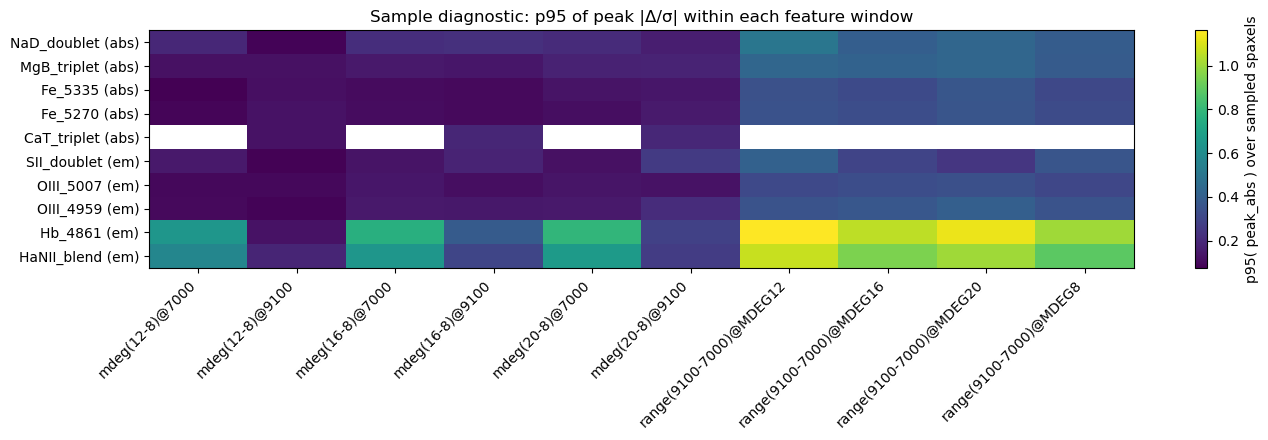

In [4]:
# -----------------------------
# Heatmap: p95(peak_abs) across spaxel sample
# -----------------------------
pivot = pivot_p95.copy().replace([np.inf, -np.inf], np.nan)

feat_order = list(pivot.index)
feat_order = sorted(feat_order, key=lambda t: (0 if t[1]=="em" else 1, t[0]))
pivot = pivot.loc[feat_order]

vals = pivot.values
fig, ax = plt.subplots(figsize=(14, max(4, 0.45*len(pivot.index))))
im = ax.imshow(vals, aspect="auto", origin="lower")

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels([f"{f} ({k})" for f,k in pivot.index])
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(list(pivot.columns), rotation=45, ha="right")

ax.set_title("Sample diagnostic: p95 of peak |Δ/σ| within each feature window")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("p95( peak_abs ) over sampled spaxels")

plt.tight_layout()
plt.show()

In [5]:
# -----------------------------
# Integrated metrics: ΔF/σF within each feature window
# -----------------------------

def dlambda_from_wave(wave_win):
    if wave_win.size < 2:
        return np.nan
    return float(np.nanmedian(np.diff(wave_win)))

def integrate_deltaF(diff_slab, dlam):
    """
    diff_slab: (Nwin, Nspax) difference in flux density units
    returns ΔF per spaxel: sum(diff)*dλ
    """
    return np.nansum(diff_slab, axis=0) * dlam

def integrate_sigmaF(noise_samp, n_eff, dlam):
    """
    noise_samp: (Nspax,) scalar σ0 per spaxel (from noise_map)
    n_eff: (Nspax,) effective number of finite wavelength samples in window
    returns σF ≈ σ0 * sqrt(n_eff) * dλ
    """
    return noise_samp * np.sqrt(np.clip(n_eff, 0, None)) * dlam

def n_eff_from_slab(diff_slab):
    return np.sum(np.isfinite(diff_slab), axis=0).astype(float)

def fluxsig_ratio(diff_slab, noise_samp, dlam):
    """
    returns signed ratio r = ΔF/σF and abs(r)
    """
    n_eff = n_eff_from_slab(diff_slab)
    dF = integrate_deltaF(diff_slab, dlam)
    sF = integrate_sigmaF(noise_samp, n_eff, dlam)

    r = dF / np.where(sF > 0, sF, np.nan)
    return r, np.abs(r)

In [6]:
# -----------------------------
# Single spaxel: integrated ΔF/σF by feature and comparison
# -----------------------------

def spaxel_fluxsig_table(x, y, base_mdeg=8, mdegs=(8,12,16,20)):
    sigma0 = noise_map[y, x]
    if not np.isfinite(sigma0) or sigma0 <= 0:
        raise RuntimeError("Invalid sigma at this spaxel (noise_map).")

    rows = []
    for feat, meta in obs_windows.items():
        w1, w2 = meta["w1"], meta["w2"]

        m7000 = window_mask(wave_7000, w1, w2)
        m9100 = window_mask(wave_9100, w1, w2)

        # ----- Range effect (9100-7000) evaluated on 7000 grid -----
        if m7000.any():
            wwin = wave_7000[m7000]
            dlam = dlambda_from_wave(wwin)

            for mdeg in mdegs:
                s7000 = cubes_7000[mdeg][m7000, y, x]
                s9100_on_7000 = interp_cube_to_waveout_window(cubes_9100[mdeg], wave_9100, wwin, y, x)
                diff = (s9100_on_7000 - s7000)  # flux density difference
                # treat as slab shape (Nwin,1)
                r, rabs = fluxsig_ratio(diff[:, None], np.array([sigma0]), dlam)

                rows.append({
                    "feature": feat, "kind": meta["kind"],
                    "comparison": f"range(9100-7000)@MDEG{mdeg}",
                    "dF_over_sF": float(r[0]),
                    "abs_dF_over_sF": float(rabs[0]),
                })

        # ----- MDEG effect within 7000 -----
        if m7000.any():
            wwin = wave_7000[m7000]
            dlam = dlambda_from_wave(wwin)
            base = cubes_7000[base_mdeg][m7000, y, x]

            for mdeg in mdegs:
                if mdeg == base_mdeg:
                    continue
                diff = (cubes_7000[mdeg][m7000, y, x] - base)
                r, rabs = fluxsig_ratio(diff[:, None], np.array([sigma0]), dlam)

                rows.append({
                    "feature": feat, "kind": meta["kind"],
                    "comparison": f"mdeg({mdeg}-{base_mdeg})@7000",
                    "dF_over_sF": float(r[0]),
                    "abs_dF_over_sF": float(rabs[0]),
                })

        # ----- MDEG effect within 9100 -----
        if m9100.any():
            wwin = wave_9100[m9100]
            dlam = dlambda_from_wave(wwin)
            base = cubes_9100[base_mdeg][m9100, y, x]

            for mdeg in mdegs:
                if mdeg == base_mdeg:
                    continue
                diff = (cubes_9100[mdeg][m9100, y, x] - base)
                r, rabs = fluxsig_ratio(diff[:, None], np.array([sigma0]), dlam)

                rows.append({
                    "feature": feat, "kind": meta["kind"],
                    "comparison": f"mdeg({mdeg}-{base_mdeg})@9100",
                    "dF_over_sF": float(r[0]),
                    "abs_dF_over_sF": float(rabs[0]),
                })

    return pd.DataFrame(rows)

df_spx_F = spaxel_fluxsig_table(XPIX, YPIX, base_mdeg=8, mdegs=(8,12,16,20))
pivot_spx_F = df_spx_F.pivot_table(index=["feature","kind"], columns="comparison", values="abs_dF_over_sF", aggfunc="median")
display(pivot_spx_F)

,comparison,mdeg(12-8)@7000,mdeg(12-8)@9100,mdeg(16-8)@7000,mdeg(16-8)@9100,mdeg(20-8)@7000,mdeg(20-8)@9100,range(9100-7000)@MDEG12,range(9100-7000)@MDEG16,range(9100-7000)@MDEG20,range(9100-7000)@MDEG8
feature,kind,,,,,,,,,,
CaT_triplet,abs,NaN,0.373585,NaN,0.978840,NaN,0.285992,NaN,NaN,NaN,NaN
Fe_5270,abs,0.336382,0.261721,0.266894,0.175692,0.255825,0.187060,1.687054,1.319130,1.692951,1.761715
Fe_5335,abs,0.144247,0.331068,0.125193,0.138701,0.145509,0.167638,1.730367,1.530039,1.856694,1.543546
HaNII_blend,em,0.538822,0.895980,0.098971,0.236175,0.008911,0.366754,0.496909,0.716862,0.478402,0.854067
Hb_4861,em,0.218145,0.021529,1.400233,0.808464,1.052200,0.302477,4.263304,3.474919,3.316965,4.066688
MgB_triplet,abs,0.323085,0.204768,0.497550,0.143872,0.709895,0.025965,2.816769,2.581408,2.199226,2.935086
NaD_doublet,abs,0.311867,0.176845,0.005660,0.855545,0.226020,0.302865,0.341494,0.384689,0.052369,0.476516
OIII_4959,em,0.010797,0.209019,0.071523,0.222144,0.214498,0.086370,2.765088,2.273198,2.438737,2.566865
OIII_5007,em,0.185413,0.183245,0.496400,0.211238,0.432610,0.006467,2.523367,2.806361,2.947342,2.521199


In [7]:
# -----------------------------
# Sample statistics: percentiles of |ΔF/σF| across spaxels
# -----------------------------

def sample_feature_fluxsig_summary(base_mdeg=8, mdegs=(8,12,16,20), percentiles=(50, 84, 95, 99)):
    rows = []

    for feat, meta in obs_windows.items():
        w1, w2 = meta["w1"], meta["w2"]

        m7000 = window_mask(wave_7000, w1, w2)
        m9100 = window_mask(wave_9100, w1, w2)

        # ----- Range effect on 7000 grid -----
        if m7000.any():
            wwin = wave_7000[m7000]
            dlam = dlambda_from_wave(wwin)

            for mdeg in mdegs:
                slab7000 = cubes_7000[mdeg][m7000, :, :][:, ys, xs]  # (Nwin,Nspax)
                slab9100 = interp_slab_in_to_wave_out(cubes_9100[mdeg], wave_9100, wwin, ys, xs)
                diff = slab9100 - slab7000

                r, rabs = fluxsig_ratio(diff, noise_samp, dlam)

                rows.append({
                    "feature": feat, "kind": meta["kind"],
                    "comparison": f"range(9100-7000)@MDEG{mdeg}",
                    **{f"p{p}": float(np.nanpercentile(rabs, p)) for p in percentiles},
                })

        # ----- MDEG effect within 7000 -----
        if m7000.any():
            wwin = wave_7000[m7000]
            dlam = dlambda_from_wave(wwin)
            base_slab = cubes_7000[base_mdeg][m7000, :, :][:, ys, xs]

            for mdeg in mdegs:
                if mdeg == base_mdeg:
                    continue
                slab = cubes_7000[mdeg][m7000, :, :][:, ys, xs]
                diff = slab - base_slab

                r, rabs = fluxsig_ratio(diff, noise_samp, dlam)

                rows.append({
                    "feature": feat, "kind": meta["kind"],
                    "comparison": f"mdeg({mdeg}-{base_mdeg})@7000",
                    **{f"p{p}": float(np.nanpercentile(rabs, p)) for p in percentiles},
                })

        # ----- MDEG effect within 9100 -----
        if m9100.any():
            wwin = wave_9100[m9100]
            dlam = dlambda_from_wave(wwin)
            base_slab = cubes_9100[base_mdeg][m9100, :, :][:, ys, xs]

            for mdeg in mdegs:
                if mdeg == base_mdeg:
                    continue
                slab = cubes_9100[mdeg][m9100, :, :][:, ys, xs]
                diff = slab - base_slab

                r, rabs = fluxsig_ratio(diff, noise_samp, dlam)

                rows.append({
                    "feature": feat, "kind": meta["kind"],
                    "comparison": f"mdeg({mdeg}-{base_mdeg})@9100",
                    **{f"p{p}": float(np.nanpercentile(rabs, p)) for p in percentiles},
                })

    return pd.DataFrame(rows)

df_samp_F = sample_feature_fluxsig_summary(base_mdeg=8, mdegs=(8,12,16,20), percentiles=(50,84,95,99))

pivot_p95_F = df_samp_F.pivot_table(index=["feature","kind"], columns="comparison", values="p95", aggfunc="median")
display(pivot_p95_F)

,comparison,mdeg(12-8)@7000,mdeg(12-8)@9100,mdeg(16-8)@7000,mdeg(16-8)@9100,mdeg(20-8)@7000,mdeg(20-8)@9100,range(9100-7000)@MDEG12,range(9100-7000)@MDEG16,range(9100-7000)@MDEG20,range(9100-7000)@MDEG8
feature,kind,,,,,,,,,,
CaT_triplet,abs,NaN,0.608719,NaN,1.079785,NaN,0.629018,NaN,NaN,NaN,NaN
Fe_5270,abs,0.163234,0.339153,0.185437,0.237082,0.201487,0.314388,0.872027,0.833666,0.873762,0.832450
Fe_5335,abs,0.141189,0.320562,0.218351,0.198745,0.309678,0.334640,0.846880,0.802235,0.914664,0.831137
HaNII_blend,em,0.574131,0.824489,0.656202,0.443968,0.995571,0.442077,1.797385,1.956185,2.135758,1.886232
Hb_4861,em,1.281054,0.290308,1.551146,0.874533,1.651188,0.565760,2.425744,2.358455,2.463570,2.308609
MgB_triplet,abs,0.211821,0.272833,0.263405,0.362672,0.443426,0.504784,1.298180,1.288368,1.307478,1.277569
NaD_doublet,abs,0.525601,0.290991,0.529399,0.686449,0.522798,0.489094,1.357037,1.037116,1.155753,1.030320
OIII_4959,em,0.265202,0.181169,0.391800,0.347254,0.388538,0.491593,0.899303,0.928844,1.015772,0.897594
OIII_5007,em,0.247001,0.264758,0.359517,0.273581,0.351734,0.309242,0.833950,0.885608,0.899770,0.816390


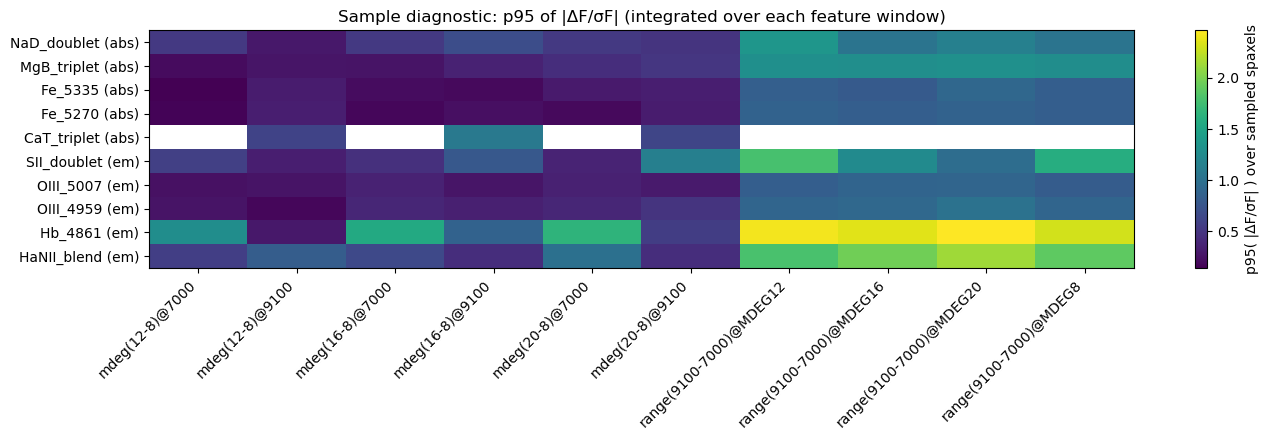

In [8]:
# -----------------------------
# Heatmap: p95 of |ΔF/σF| across spaxel sample
# -----------------------------
pivot = pivot_p95_F.copy().replace([np.inf, -np.inf], np.nan)

feat_order = list(pivot.index)
feat_order = sorted(feat_order, key=lambda t: (0 if t[1]=="em" else 1, t[0]))
pivot = pivot.loc[feat_order]

vals = pivot.values
fig, ax = plt.subplots(figsize=(14, max(4, 0.45*len(pivot.index))))
im = ax.imshow(vals, aspect="auto", origin="lower")

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels([f"{f} ({k})" for f,k in pivot.index])
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(list(pivot.columns), rotation=45, ha="right")

ax.set_title("Sample diagnostic: p95 of |ΔF/σF| (integrated over each feature window)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("p95( |ΔF/σF| ) over sampled spaxels")

plt.tight_layout()
plt.show()

In [9]:
# ============================
# Cell A: Map of |ΔF/σF| and top-5% mask (strided)
# ============================

# --- USER CHOICES ---
FEATURE_NAME = "Hb_4861"     # e.g. "Hb_4861", "HaNII_blend", "NaD_doublet", ...
MDEG_MAP     = 8            # for range(9100-7000) at fixed MDEG
STRIDE_MAP   = STRIDE       # use your existing STRIDE
TOP_PCT      = 95           # top 5% (>= p95)

def interp_cube_strided_to_waveout(cube_in, wave_in, wave_out_win, stride):
    """
    Interpolate cube_in (Nλ, Ny, Nx) onto wave_out_win, returning slab_out (Nwin, Ny', Nx')
    where Ny'=Ny//stride and Nx'=Nx//stride (using ::stride slicing).
    """
    j = np.searchsorted(wave_in, wave_out_win)
    j = np.clip(j, 1, len(wave_in) - 1)
    j0 = j - 1
    j1 = j

    x0 = wave_in[j0]
    x1 = wave_in[j1]
    w = (wave_out_win - x0) / (x1 - x0 + 1e-30)  # avoid /0

    y0 = cube_in[j0, ::stride, ::stride]  # (Nwin, Ny', Nx')
    y1 = cube_in[j1, ::stride, ::stride]
    return y0 * (1.0 - w[:, None, None]) + y1 * (w[:, None, None])

def map_abs_dF_over_sF_range(feature_name, mdeg, stride):
    # window in observed frame
    w1, w2 = obs_windows[feature_name]["w1"], obs_windows[feature_name]["w2"]
    m7000 = window_mask(wave_7000, w1, w2)
    if not m7000.any():
        raise RuntimeError(f"Feature window {feature_name} not covered by wave_7000")

    wwin = wave_7000[m7000]
    dlam = dlambda_from_wave(wwin)

    # slabs on strided grid
    slab7000 = cubes_7000[mdeg][m7000, ::stride, ::stride]                  # (Nwin, Ny', Nx')
    slab9100 = interp_cube_strided_to_waveout(cubes_9100[mdeg], wave_9100, wwin, stride)

    diff = slab9100 - slab7000                                              # (Nwin, Ny', Nx')

    # noise per spaxel (scalar sigma0 from CONT window), strided
    sigma0 = noise_map[::stride, ::stride]                                  # (Ny', Nx')
    sigma0 = np.where(np.isfinite(sigma0) & (sigma0 > 0), sigma0, np.nan)

    # compute ΔF and σF per spaxel
    # ΔF = sum(diff)*dλ ; σF ~ σ0*sqrt(N_eff)*dλ
    n_eff = np.sum(np.isfinite(diff), axis=0).astype(float)                 # (Ny', Nx')
    dF = np.nansum(diff, axis=0) * dlam                                     # (Ny', Nx')
    sF = sigma0 * np.sqrt(np.clip(n_eff, 0, None)) * dlam

    ratio = np.abs(dF / np.where(sF > 0, sF, np.nan))                       # (Ny', Nx')

    finite = np.isfinite(ratio)
    if not finite.any():
        raise RuntimeError("No finite values in |ΔF/σF| map")

    thr = np.nanpercentile(ratio[finite], TOP_PCT)
    topmask = finite & (ratio >= thr)

    meta = {
        "feature": feature_name,
        "mdeg": mdeg,
        "stride": stride,
        "w1": w1, "w2": w2,
        "dlam": dlam,
        "thr": float(thr),
        "p99": float(np.nanpercentile(ratio[finite], 99)),
        "p95": float(np.nanpercentile(ratio[finite], 95)),
        "p50": float(np.nanpercentile(ratio[finite], 50)),
        "n_top": int(np.sum(topmask)),
        "n_tot": int(np.sum(finite)),
    }
    return ratio, topmask, meta

ratio_map, topmask_map, meta_map = map_abs_dF_over_sF_range(FEATURE_NAME, MDEG_MAP, STRIDE_MAP)

print("[MAP] |ΔF/σF|  range(9100-7000) @ MDEG =", meta_map["mdeg"])
print(f"      feature={meta_map['feature']}  window=[{meta_map['w1']:.1f},{meta_map['w2']:.1f}] Å  dλ~{meta_map['dlam']:.3g} Å")
print(f"      stride={meta_map['stride']}  finite={meta_map['n_tot']}  top(>=p{TOP_PCT})={meta_map['n_top']}  thr={meta_map['thr']:.3g}")
print(f"      p50={meta_map['p50']:.3g}  p95={meta_map['p95']:.3g}  p99={meta_map['p99']:.3g}")

[MAP] |ΔF/σF|  range(9100-7000) @ MDEG = 8
      feature=Hb_4861  window=[4882.4,4894.4] Å  dλ~1.25 Å
      stride=4  finite=6004  top(>=p95)=301  thr=2.24
      p50=0.316  p95=2.24  p99=4.93


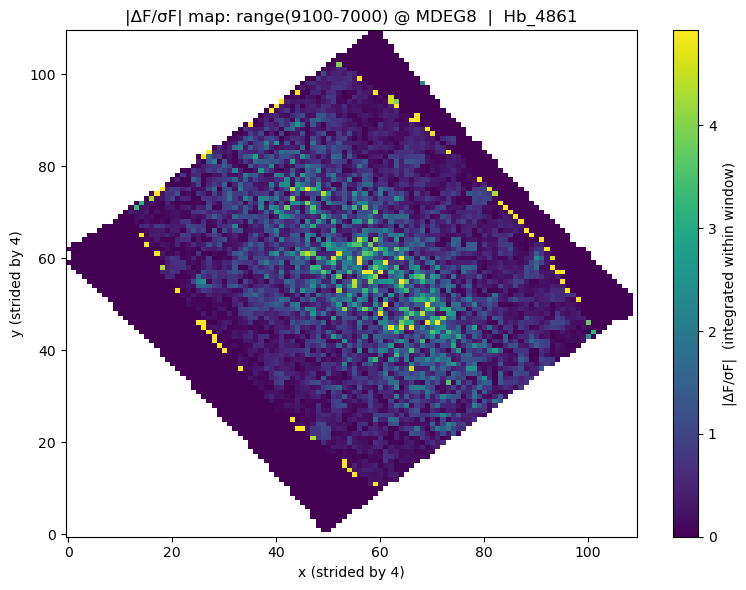

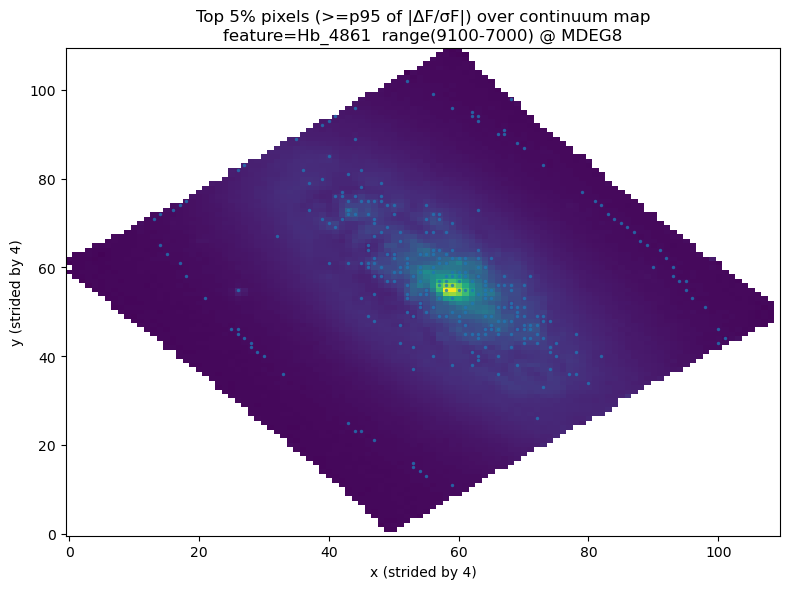


Top |ΔF/σF| locations (original pixel coords):
  |ΔF/σF|=15.2  at (x,y)=(140,356)
  |ΔF/σF|=13.5  at (x,y)=(156,368)
  |ΔF/σF|=10.5  at (x,y)=(160,372)
  |ΔF/σF|=8.82  at (x,y)=(108,332)
  |ΔF/σF|=8.67  at (x,y)=(164,376)
  |ΔF/σF|=8.61  at (x,y)=(176,384)
  |ΔF/σF|=7.45  at (x,y)=(104,328)
  |ΔF/σF|=6.35  at (x,y)=(228,228)
  |ΔF/σF|=6.3  at (x,y)=(284,184)
  |ΔF/σF|=6.25  at (x,y)=(224,240)


In [10]:
# ============================
# Cell B: Plot |ΔF/σF| map + top-5% overlay
# ============================

ny_s, nx_s = ratio_map.shape
finite = np.isfinite(ratio_map)

# scale for visualization (robust)
vmax = np.nanpercentile(ratio_map[finite], 99) if finite.any() else np.nanmax(ratio_map)
vmin = 0.0

# coordinates of top pixels in ORIGINAL pixel units
yy_s, xx_s = np.where(topmask_map)
yy = yy_s * meta_map["stride"]
xx = xx_s * meta_map["stride"]

# strided continuum background
cont_s = cont_map[::meta_map["stride"], ::meta_map["stride"]]

plt.figure(figsize=(8, 6))
plt.imshow(ratio_map, origin="lower", vmin=vmin, vmax=vmax, aspect="auto")
plt.colorbar(label="|ΔF/σF|  (integrated within window)")
plt.title(f"|ΔF/σF| map: range(9100-7000) @ MDEG{meta_map['mdeg']}  |  {meta_map['feature']}")
plt.xlabel(f"x (strided by {meta_map['stride']})")
plt.ylabel(f"y (strided by {meta_map['stride']})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(cont_s, origin="lower", aspect="auto")
plt.scatter(xx_s, yy_s, s=6, marker="o", linewidths=0, alpha=0.8)  # overlay in STRIDED coords
plt.title(f"Top {100-TOP_PCT}% pixels (>=p{TOP_PCT} of |ΔF/σF|) over continuum map\n"
          f"feature={meta_map['feature']}  range(9100-7000) @ MDEG{meta_map['mdeg']}")
plt.xlabel(f"x (strided by {meta_map['stride']})")
plt.ylabel(f"y (strided by {meta_map['stride']})")
plt.tight_layout()
plt.show()

# Optional: print a few strongest locations in ORIGINAL pixel units
flat = ratio_map.copy()
flat[~finite] = -np.inf
k = min(10, np.sum(finite))
inds = np.argpartition(flat.ravel(), -k)[-k:]
inds = inds[np.argsort(flat.ravel()[inds])[::-1]]

print("\nTop |ΔF/σF| locations (original pixel coords):")
for idx in inds:
    ys_idx, xs_idx = np.unravel_index(idx, ratio_map.shape)
    print(f"  |ΔF/σF|={ratio_map[ys_idx, xs_idx]:.3g}  at (x,y)=({xs_idx*meta_map['stride']},{ys_idx*meta_map['stride']})")

In [11]:
# ============================
# Cell 1: Baseline definition
# ============================

BASE_RANGE = "7000"
BASE_MDEG  = 8

TEST_RANGE = "9100"
TEST_MDEGS = tuple(MDEGS)   # (8,12,16,20)

def comp_label(mdeg):
    return f"{TEST_RANGE}MDEG{mdeg} - {BASE_RANGE}MDEG{BASE_MDEG}"

print("[BASE] ", f"{BASE_RANGE} MDEG={BASE_MDEG}")
print("[TEST] ", f"{TEST_RANGE} MDEGs={TEST_MDEGS}")

[BASE]  7000 MDEG=8
[TEST]  9100 MDEGs=(8, 12, 16, 20)


,comparison,9100MDEG12 - 7000MDEG8,9100MDEG16 - 7000MDEG8,9100MDEG20 - 7000MDEG8,9100MDEG8 - 7000MDEG8
feature,kind,,,,
Fe_5270,abs,0.748694,0.678414,0.787094,0.722487
Fe_5335,abs,0.565375,0.478838,0.543323,0.483539
HaNII_blend,em,0.525927,0.845327,0.644599,0.676988
Hb_4861,em,1.358214,1.639019,1.454586,1.391246
MgB_triplet,abs,0.754631,0.826820,0.783873,0.790453
NaD_doublet,abs,0.272790,0.363547,0.230373,0.235435
OIII_4959,em,0.947590,0.823762,0.951558,0.903274
OIII_5007,em,0.795554,0.786622,0.868478,0.862473
SII_doublet,em,0.110256,0.240287,0.333732,0.056225


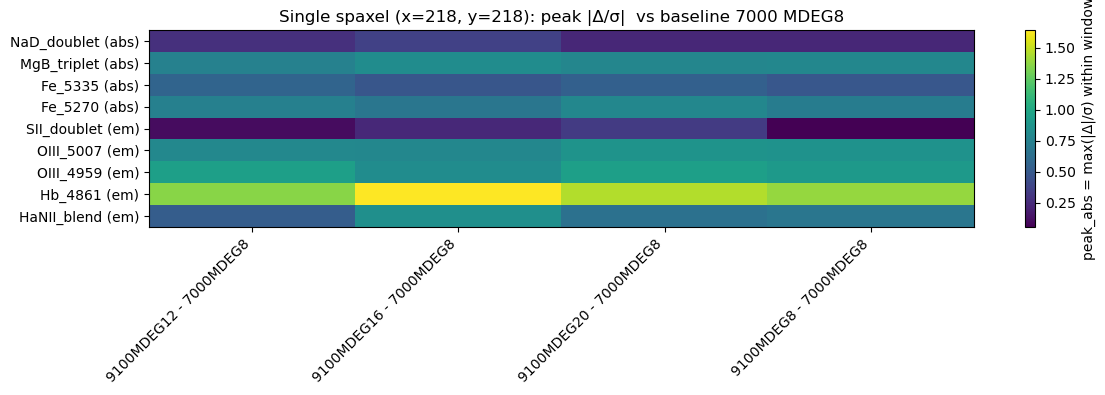

In [12]:
# ============================
# Cell 2: Single-spaxel PEAK metric vs baseline
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def spaxel_peak_vs_baseline(x, y, test_mdegs=TEST_MDEGS):
    sigma0 = noise_map[y, x]
    if not np.isfinite(sigma0) or sigma0 <= 0:
        raise RuntimeError("Invalid sigma at this spaxel (noise_map).")

    rows = []
    for feat, meta in obs_windows.items():
        w1, w2 = meta["w1"], meta["w2"]

        # Must exist on 7000 grid since baseline is 7000
        m7000 = window_mask(wave_7000, w1, w2)
        if not m7000.any():
            continue  # skip features not covered by baseline (e.g. CaT)

        wwin = wave_7000[m7000]
        base_spec = cubes_7000[BASE_MDEG][m7000, y, x]

        for mdeg in test_mdegs:
            test_interp = interp_cube_to_waveout_window(cubes_9100[mdeg], wave_9100, wwin, y, x)
            d = (test_interp - base_spec) / sigma0
            pabs, ppos, pneg = peak_metrics_from_curve(d)

            rows.append({
                "feature": feat,
                "kind": meta["kind"],
                "comparison": comp_label(mdeg),
                "peak_abs": pabs,
                "peak_pos": ppos,
                "peak_neg": pneg,
            })

    df = pd.DataFrame(rows)
    piv = df.pivot_table(index=["feature","kind"], columns="comparison", values="peak_abs", aggfunc="median")
    return df, piv

df_spx_peak_base, pivot_spx_peak_base = spaxel_peak_vs_baseline(XPIX, YPIX, TEST_MDEGS)
display(pivot_spx_peak_base)

# Heatmap
pivot = pivot_spx_peak_base.copy().replace([np.inf, -np.inf], np.nan)
feat_order = sorted(list(pivot.index), key=lambda t: (0 if t[1]=="em" else 1, t[0]))
pivot = pivot.loc[feat_order]

vals = pivot.values
fig, ax = plt.subplots(figsize=(12, max(4, 0.45*len(pivot.index))))
im = ax.imshow(vals, aspect="auto", origin="lower")
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels([f"{f} ({k})" for f,k in pivot.index])
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(list(pivot.columns), rotation=45, ha="right")
ax.set_title(f"Single spaxel (x={XPIX}, y={YPIX}): peak |Δ/σ|  vs baseline {BASE_RANGE} MDEG{BASE_MDEG}")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("peak_abs = max(|Δ|/σ) within window")
plt.tight_layout()
plt.show()

,comparison,9100MDEG12 - 7000MDEG8,9100MDEG16 - 7000MDEG8,9100MDEG20 - 7000MDEG8,9100MDEG8 - 7000MDEG8
feature,kind,,,,
Fe_5270,abs,2.023436,1.586023,1.948776,1.761715
Fe_5335,abs,1.874614,1.404845,1.711184,1.543546
HaNII_blend,em,0.041913,0.617892,0.487313,0.854067
Hb_4861,em,4.045159,4.875152,4.369165,4.066688
MgB_triplet,abs,3.139854,3.078958,2.909121,2.935086
NaD_doublet,abs,0.653361,0.379029,0.173651,0.476516
OIII_4959,em,2.775884,2.344721,2.653235,2.566865
OIII_5007,em,2.337954,2.309962,2.514732,2.521199
SII_doublet,em,0.323919,0.870188,1.366009,0.010296


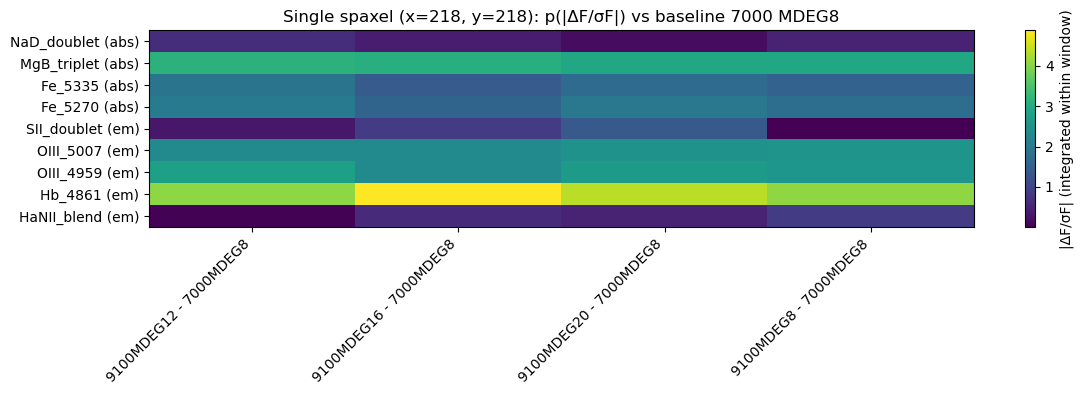

In [13]:
# ============================
# Cell 3: Single-spaxel INTEGRATED metric vs baseline
# ============================

def spaxel_int_vs_baseline(x, y, test_mdegs=TEST_MDEGS):
    sigma0 = noise_map[y, x]
    if not np.isfinite(sigma0) or sigma0 <= 0:
        raise RuntimeError("Invalid sigma at this spaxel (noise_map).")

    rows = []
    for feat, meta in obs_windows.items():
        w1, w2 = meta["w1"], meta["w2"]

        m7000 = window_mask(wave_7000, w1, w2)
        if not m7000.any():
            continue

        wwin = wave_7000[m7000]
        dlam = dlambda_from_wave(wwin)
        base_spec = cubes_7000[BASE_MDEG][m7000, y, x]

        for mdeg in test_mdegs:
            test_interp = interp_cube_to_waveout_window(cubes_9100[mdeg], wave_9100, wwin, y, x)
            diff = (test_interp - base_spec)  # flux-density difference

            r, rabs = fluxsig_ratio(diff[:, None], np.array([sigma0]), dlam)

            rows.append({
                "feature": feat,
                "kind": meta["kind"],
                "comparison": comp_label(mdeg),
                "dF_over_sF": float(r[0]),
                "abs_dF_over_sF": float(rabs[0]),
            })

    df = pd.DataFrame(rows)
    piv = df.pivot_table(index=["feature","kind"], columns="comparison", values="abs_dF_over_sF", aggfunc="median")
    return df, piv

df_spx_int_base, pivot_spx_int_base = spaxel_int_vs_baseline(XPIX, YPIX, TEST_MDEGS)
display(pivot_spx_int_base)

# Heatmap
pivot = pivot_spx_int_base.copy().replace([np.inf, -np.inf], np.nan)
feat_order = sorted(list(pivot.index), key=lambda t: (0 if t[1]=="em" else 1, t[0]))
pivot = pivot.loc[feat_order]

vals = pivot.values
fig, ax = plt.subplots(figsize=(12, max(4, 0.45*len(pivot.index))))
im = ax.imshow(vals, aspect="auto", origin="lower")
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels([f"{f} ({k})" for f,k in pivot.index])
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(list(pivot.columns), rotation=45, ha="right")
ax.set_title(f"Single spaxel (x={XPIX}, y={YPIX}): p(|ΔF/σF|) vs baseline {BASE_RANGE} MDEG{BASE_MDEG}")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("|ΔF/σF| (integrated within window)")
plt.tight_layout()
plt.show()

,comparison,9100MDEG12 - 7000MDEG8,9100MDEG16 - 7000MDEG8,9100MDEG20 - 7000MDEG8,9100MDEG8 - 7000MDEG8
feature,kind,,,,
Fe_5270,abs,0.346096,0.329158,0.348289,0.323538
Fe_5335,abs,0.320227,0.314874,0.324397,0.311112
HaNII_blend,em,0.871970,0.999925,0.969404,0.889091
Hb_4861,em,0.992273,1.149644,1.077027,1.005658
MgB_triplet,abs,0.409088,0.402294,0.425703,0.388030
NaD_doublet,abs,0.405734,0.400912,0.391885,0.392096
OIII_4959,em,0.348427,0.386563,0.374319,0.353456
OIII_5007,em,0.309710,0.309348,0.324936,0.306976
SII_doublet,em,0.302865,0.236966,0.226161,0.360815


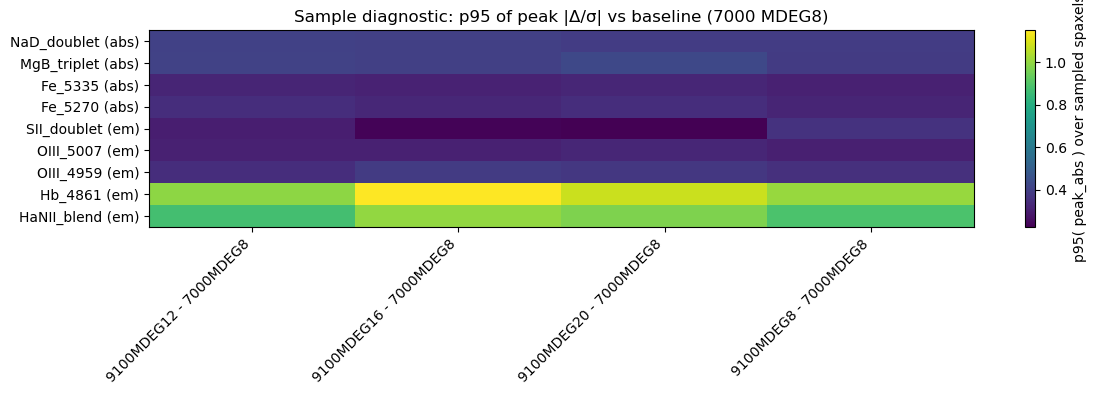

In [14]:
# ============================
# Cell 4: Sample p95 of PEAK metric vs baseline
# ============================

def sample_pXX_peak_vs_baseline(test_mdegs=TEST_MDEGS, percentiles=(50,84,95,99)):
    rows = []
    for feat, meta in obs_windows.items():
        w1, w2 = meta["w1"], meta["w2"]

        m7000 = window_mask(wave_7000, w1, w2)
        if not m7000.any():
            continue

        wwin = wave_7000[m7000]
        base_slab = cubes_7000[BASE_MDEG][m7000, :, :][:, ys, xs]  # (Nwin,Nspax)

        for mdeg in test_mdegs:
            test_slab = interp_slab_in_to_wave_out(cubes_9100[mdeg], wave_9100, wwin, ys, xs)
            diff = test_slab - base_slab
            peak = np.nanmax(np.abs(diff / noise_samp[None, :]), axis=0)

            rows.append({
                "feature": feat,
                "kind": meta["kind"],
                "comparison": comp_label(mdeg),
                **{f"p{p}": float(np.nanpercentile(peak, p)) for p in percentiles},
            })

    return pd.DataFrame(rows)

df_samp_peak_base = sample_pXX_peak_vs_baseline(TEST_MDEGS, percentiles=(50,84,95,99))
pivot_p95_peak_base = df_samp_peak_base.pivot_table(index=["feature","kind"], columns="comparison", values="p95", aggfunc="median")
display(pivot_p95_peak_base)

# Heatmap
pivot = pivot_p95_peak_base.copy().replace([np.inf, -np.inf], np.nan)
feat_order = sorted(list(pivot.index), key=lambda t: (0 if t[1]=="em" else 1, t[0]))
pivot = pivot.loc[feat_order]

vals = pivot.values
fig, ax = plt.subplots(figsize=(12, max(4, 0.45*len(pivot.index))))
im = ax.imshow(vals, aspect="auto", origin="lower")
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels([f"{f} ({k})" for f,k in pivot.index])
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(list(pivot.columns), rotation=45, ha="right")
ax.set_title("Sample diagnostic: p95 of peak |Δ/σ| vs baseline (7000 MDEG8)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("p95( peak_abs ) over sampled spaxels")
plt.tight_layout()
plt.show()

,comparison,9100MDEG12 - 7000MDEG8,9100MDEG16 - 7000MDEG8,9100MDEG20 - 7000MDEG8,9100MDEG8 - 7000MDEG8
feature,kind,,,,
Fe_5270,abs,0.920255,0.832578,0.891406,0.832450
Fe_5335,abs,0.830285,0.834370,0.840053,0.831137
HaNII_blend,em,1.677746,1.827465,1.811409,1.886232
Hb_4861,em,2.276094,2.664549,2.429917,2.308609
MgB_triplet,abs,1.316626,1.309772,1.403168,1.277569
NaD_doublet,abs,1.101298,1.074026,1.074318,1.030320
OIII_4959,em,0.887860,0.999139,0.948928,0.897594
OIII_5007,em,0.825217,0.829598,0.869656,0.816390
SII_doublet,em,1.310780,1.011426,0.959888,1.589067


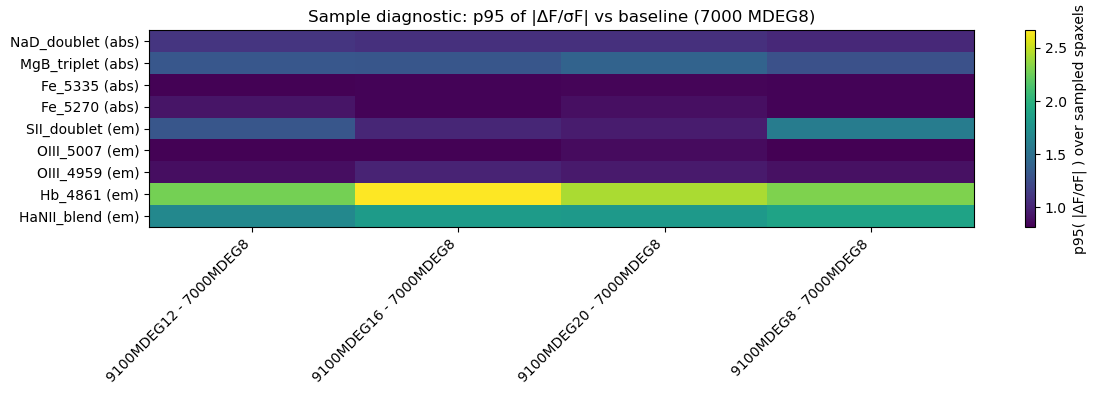

In [15]:
# ============================
# Cell 5: Sample p95 of INTEGRATED metric vs baseline
# ============================

def sample_pXX_int_vs_baseline(test_mdegs=TEST_MDEGS, percentiles=(50,84,95,99)):
    rows = []
    for feat, meta in obs_windows.items():
        w1, w2 = meta["w1"], meta["w2"]

        m7000 = window_mask(wave_7000, w1, w2)
        if not m7000.any():
            continue

        wwin = wave_7000[m7000]
        dlam = dlambda_from_wave(wwin)

        base_slab = cubes_7000[BASE_MDEG][m7000, :, :][:, ys, xs]

        for mdeg in test_mdegs:
            test_slab = interp_slab_in_to_wave_out(cubes_9100[mdeg], wave_9100, wwin, ys, xs)
            diff = test_slab - base_slab

            r, rabs = fluxsig_ratio(diff, noise_samp, dlam)

            rows.append({
                "feature": feat,
                "kind": meta["kind"],
                "comparison": comp_label(mdeg),
                **{f"p{p}": float(np.nanpercentile(rabs, p)) for p in percentiles},
            })

    return pd.DataFrame(rows)

df_samp_int_base = sample_pXX_int_vs_baseline(TEST_MDEGS, percentiles=(50,84,95,99))
pivot_p95_int_base = df_samp_int_base.pivot_table(index=["feature","kind"], columns="comparison", values="p95", aggfunc="median")
display(pivot_p95_int_base)

# Heatmap
pivot = pivot_p95_int_base.copy().replace([np.inf, -np.inf], np.nan)
feat_order = sorted(list(pivot.index), key=lambda t: (0 if t[1]=="em" else 1, t[0]))
pivot = pivot.loc[feat_order]

vals = pivot.values
fig, ax = plt.subplots(figsize=(12, max(4, 0.45*len(pivot.index))))
im = ax.imshow(vals, aspect="auto", origin="lower")
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels([f"{f} ({k})" for f,k in pivot.index])
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(list(pivot.columns), rotation=45, ha="right")
ax.set_title("Sample diagnostic: p95 of |ΔF/σF| vs baseline (7000 MDEG8)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("p95( |ΔF/σF| ) over sampled spaxels")
plt.tight_layout()
plt.show()

In [17]:
# ============================
# Cell 6: Rank which 9100 MDEG is closest to 7000 MDEG8
# ============================

# Choose what you want to optimize:
USE_METRIC = "int"      # "int" or "peak"
USE_KIND   = "all"       # "em", "abs", or "all"

if USE_METRIC == "int":
    piv = pivot_p95_int_base.copy()
    metric_name = "p95(|ΔF/σF|)"
else:
    piv = pivot_p95_peak_base.copy()
    metric_name = "p95(peak |Δ/σ|)"

# Filter windows
if USE_KIND != "all":
    piv = piv.loc[[idx for idx in piv.index if idx[1] == USE_KIND], :]

# Compute a simple score: mean across selected windows (lower = closer to baseline)
scores = []
for mdeg in TEST_MDEGS:
    col = comp_label(mdeg)
    arr = piv[col].to_numpy()
    score = float(np.nanmean(arr))
    scores.append({"mdeg_9100": mdeg, "score": score})

rank_df = pd.DataFrame(scores).sort_values("score", ascending=True).reset_index(drop=True)
print(f"[RANK] optimizing {metric_name} over kind={USE_KIND} windows (lower is better)")
display(rank_df)

[RANK] optimizing p95(|ΔF/σF|) over kind=all windows (lower is better)


,mdeg_9100,score
0,12,1.238462
1,20,1.247638
2,16,1.264769
3,8,1.274374
